# 11 · Meningeal swelling along the surface

Each section's outer surface is traced and cut into **100 µm segments**. Every surface-meninges nucleus
(≤ 80 µm deep; flaps / roots excluded) is assigned to its nearest surface point, giving per segment:

* **cellularity** – meningeal nuclei per 100 µm of surface (the main swelling measure: a swollen
  meninges has more cells stacked over the same stretch of surface);
* **Pu.1⁺ per 100 µm** – the myeloid part of it;
* **thickness** – 90th percentile depth of its meningeal nuclei. Secondary: the meninges boundary always
  includes the outer 10 µm and only grows into very compact tissue, so thickness has a floor at ~10 µm
  and responds less than cellularity;
* **distance to the nearest automatic lesion** from the segment midpoint.

A segment counts as **swollen** when its cellularity exceeds the 95th percentile of control-section
segments (what an uninflamed surface looks like). Statistics use the section as the unit (replicate slides
averaged).

**Caveat – manual cores cap the meninges.** The meninges boundary never enters a manual lesion core
(notebook 05). Where an annotated core reaches the surface there are no meningeal nuclei by construction,
so swelling next to annotated lesions is *under*-estimated (e.g. R1_3_L below).

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

from scipy.stats import mannwhitneyu, wilcoxon
from lesionseg import expression as E, morphology as M, swelling as S
seg = pd.concat([S.surface_segments(r) for r in runs], ignore_index=True)
seg["cls"] = S.segment_class(seg)
THR = float(np.percentile(seg.loc[~seg.lesion_section, "cells_per_100um"], 95))
seg["swollen"] = seg.cells_per_100um > THR
print(f"{len(seg):,} segments of 100 µm in {seg.groupby(['scene', 'section']).ngroups} slide × sections; "
      f"swollen = more than {THR:.1f} meningeal nuclei per 100 µm (control p95)")
CLS = ["control section", "far from lesion", "near lesion"]
CCOL = {"control section": "#898781", "far from lesion": "#3987e5", "near lesion": "#e66767"}
summ = seg.groupby("cls").agg(segments=("segment", "size"), cells_per_100um=("cells_per_100um", "median"),
                              pu1_per_100um=("pu1_per_100um", "median"), thickness_um=("thickness_um", "median"),
                              swollen_pct=("swollen", lambda v: 100 * v.mean())).reindex(CLS)
summ.round(2)

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


3,422 segments of 100 µm in 36 slide × sections; swollen = more than 13.8 meningeal nuclei per 100 µm (control p95)


,segments,cells_per_100um,pu1_per_100um,thickness_um,swollen_pct
cls,,,,,
control section,1874,3.18,0.00,11.34,5.02
far from lesion,943,4.22,1.04,11.92,9.65
near lesion,605,7.47,1.08,13.08,30.25


## Cellularity against distance to the nearest lesion (lesion sections; median per slide)

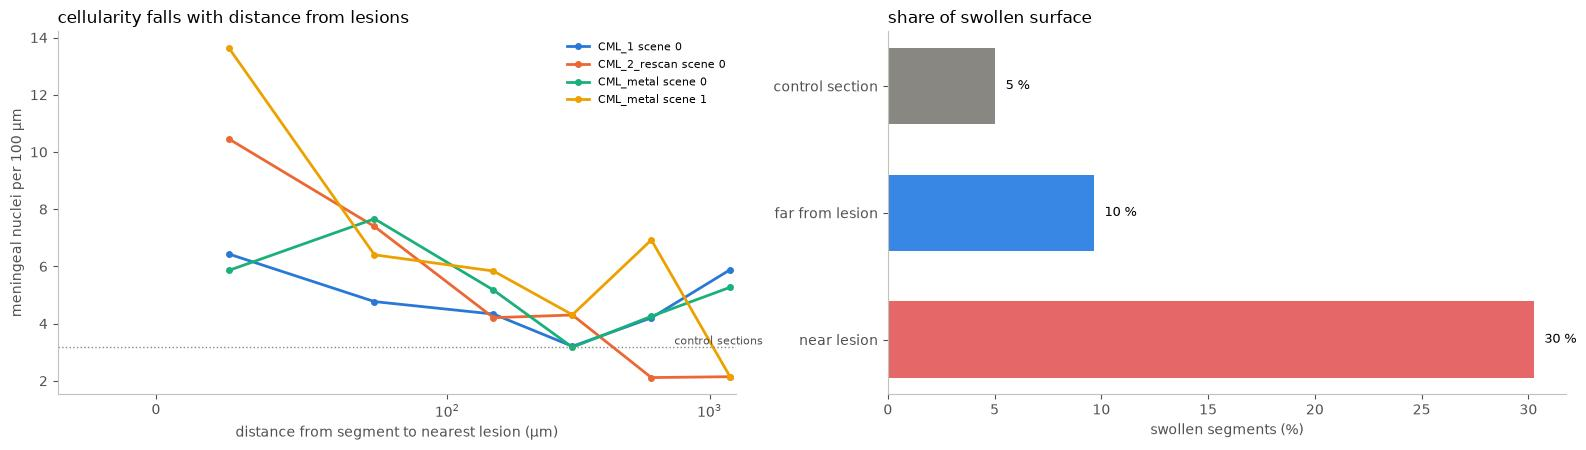

In [2]:
les = seg[seg.lesion_section].copy()
edges = [0, 50, 100, 200, 400, 800, 1600]
les["db"] = pd.cut(les.dist_to_lesion_um.clip(lower=0), edges, include_lowest=True)
g = les.groupby(["scene", "db"], observed=True).cells_per_100um.median().reset_index()
g["mid"] = g.db.map(lambda iv: iv.mid).astype(float)
ctrl = seg[~seg.lesion_section].cells_per_100um.median()
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
for (scene, d), col in zip(g.groupby("scene"), E.SCENE_COLORS):
    axes[0].plot(d.mid, d.cells_per_100um, color=col, lw=2, marker="o", ms=4, label=scene)
axes[0].axhline(ctrl, color="#898781", lw=1, ls=":"); axes[0].text(edges[-1], ctrl, " control sections", va="bottom", ha="right", fontsize=8, color="#52514e")
axes[0].set_xscale("symlog", linthresh=100); axes[0].set_xlabel("distance from segment to nearest lesion (µm)")
axes[0].set_ylabel("meningeal nuclei per 100 µm"); axes[0].set_title("cellularity falls with distance from lesions", loc="left")
axes[0].legend(fontsize=8, frameon=False)
sw = seg.groupby("cls").swollen.mean().reindex(CLS) * 100
axes[1].barh(CLS, sw, color=[CCOL[c] for c in CLS], height=0.6)
for i, v in enumerate(sw):
    axes[1].text(v + 0.5, i, f"{v:.0f} %", va="center", fontsize=9)
axes[1].set_xlabel("swollen segments (%)"); axes[1].set_title("share of swollen surface", loc="left"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## Per section: near vs far from lesions (paired), lesion vs control sections

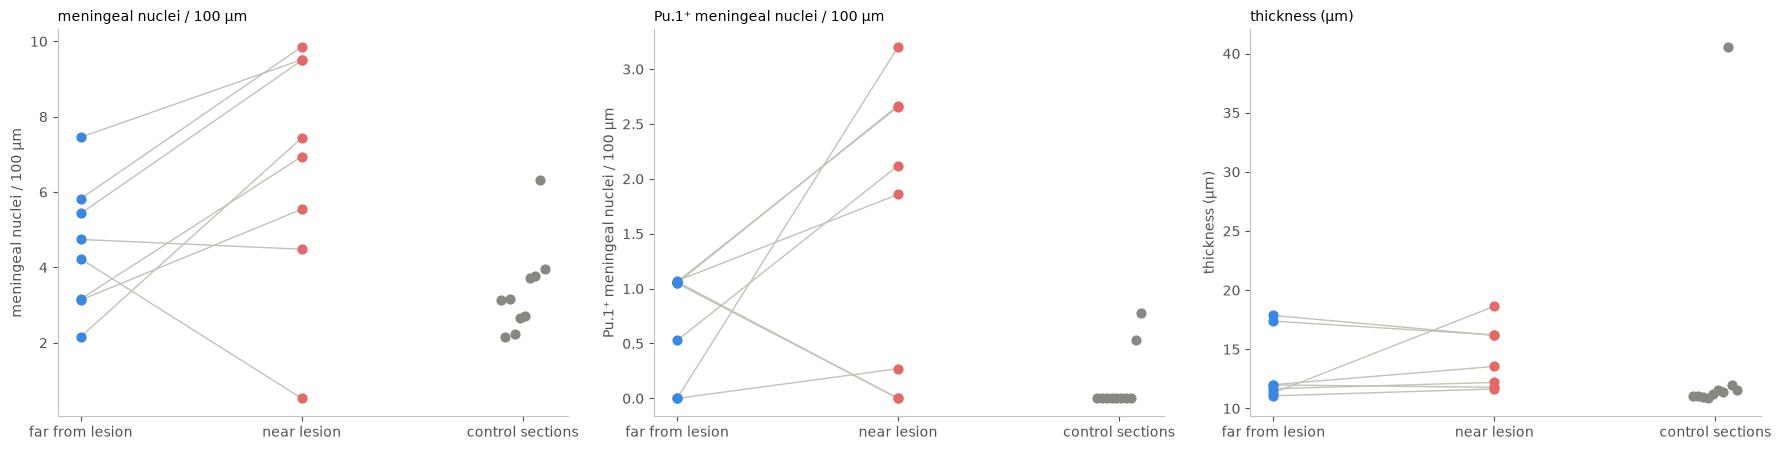

,measure,sections_paired,near_higher,median_near_minus_far,wilcoxon_p_near_far,lesion_sections_median,control_sections_median,mannwhitney_p_lesion_vs_control
0,meningeal nuclei / 100 µm,8,6,3.0946,0.0781,5.2725,3.1535,0.0205
1,Pu.1⁺ meningeal nuclei / 100 µm,8,6,1.1898,0.1484,0.9261,0.0000,0.0129
2,thickness (µm),7,4,0.5366,0.6875,11.9444,11.3156,0.1011


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
tests = []
for ax, v, lab in zip(axes, ["cells_per_100um", "pu1_per_100um", "thickness_um"],
                      ["meningeal nuclei / 100 µm", "Pu.1⁺ meningeal nuclei / 100 µm", "thickness (µm)"]):
    p = S.paired_near_far(seg, v)
    for _, r in p.iterrows():
        ax.plot([0, 1], [r["far from lesion"], r["near lesion"]], color="#c3c2b7", lw=1)
    ax.scatter(np.zeros(len(p)), p["far from lesion"], color=CCOL["far from lesion"], s=40, zorder=3)
    ax.scatter(np.ones(len(p)), p["near lesion"], color=CCOL["near lesion"], s=40, zorder=3)
    sec = seg.groupby(["scene", "section", "lesion_section"])[v].median().groupby(["section", "lesion_section"]).mean().reset_index()
    cv = sec[~sec.lesion_section][v]
    ax.scatter(np.full(len(cv), 2) + np.linspace(-0.1, 0.1, len(cv)), cv, color=CCOL["control section"], s=40, zorder=3)
    ax.set_xticks([0, 1, 2], ["far from lesion", "near lesion", "control sections"]); ax.set_ylabel(lab)
    ax.set_title(lab, loc="left", fontsize=10)
    lv = sec[sec.lesion_section][v]
    tests.append({"measure": lab, "sections_paired": len(p), "near_higher": int((p.delta > 0).sum()),
                  "median_near_minus_far": p.delta.median(), "wilcoxon_p_near_far": wilcoxon(p.delta).pvalue if len(p) >= 6 else np.nan,
                  "lesion_sections_median": lv.median(), "control_sections_median": cv.median(),
                  "mannwhitney_p_lesion_vs_control": mannwhitneyu(lv, cv).pvalue})
plt.tight_layout(); plt.show()
pd.DataFrame(tests).round(4)

## Per section, animal and level

In [4]:
st = S.section_table(seg.assign(cells_per_100um=seg.cells_per_100um), THR)
sw_sec = seg.groupby(["scene", "section"]).swollen.mean().mul(100).rename("swollen_cellularity_pct")
st = st.merge(sw_sec.reset_index(), on=["scene", "section"]).drop(columns="swollen_pct")
display(st.round(2))
display(st.groupby(["animal"])[["cells_per_100um", "pu1_per_100um", "swollen_cellularity_pct"]].median().round(2))
display(st.groupby(["level", "lesion_section"])[["cells_per_100um", "pu1_per_100um", "swollen_cellularity_pct"]].median().round(2))

,scene,section,animal,level,lesion_section,segments,surface_mm,thickness_median_um,thickness_p90_um,cells_per_100um,pu1_per_100um,swollen_cellularity_pct
0,CML_1 scene 0,OS1_2_,OS1_2,,False,80,7.48,10.36,13.80,2.27,0.00,2.50
1,CML_1 scene 0,OS1_2_C,OS1_2,C,False,104,9.73,11.15,15.20,2.15,0.00,2.88
2,CML_1 scene 0,OS1_2_L,OS1_2,L,False,92,8.59,11.94,30.67,3.23,0.00,9.78
3,CML_1 scene 0,P2_3_C,P2_3,C,True,96,9.02,12.02,24.78,5.31,1.09,9.38
4,CML_1 scene 0,P2_3_L,P2_3,L,True,77,7.24,12.08,17.54,5.25,0.00,10.39
5,CML_1 scene 0,P2_3_T,P2_3,T,True,62,5.78,11.61,22.04,7.46,1.06,16.13
6,CML_1 scene 0,R1_3_C,R1_3,C,False,98,9.19,11.78,25.48,4.21,1.04,12.24
7,CML_1 scene 0,R1_3_L,R1_3,L,True,72,6.81,11.23,12.74,4.20,1.07,2.78
8,CML_1 scene 0,R1_3_T,R1_3,T,True,78,7.31,11.03,13.07,3.21,0.00,6.41
9,CML_2_rescan scene 0,CFA_L2_C,CFA_L2,C,False,110,10.33,11.06,16.37,3.18,0.00,0.91


,cells_per_100um,pu1_per_100um,swollen_cellularity_pct
animal,,,
CFA_L2,3.13,0.00,1.07
OS1_2,2.22,0.00,2.69
P2_3,5.29,1.06,11.95
P3_1,3.73,0.00,8.62
R1_2,5.77,0.00,18.47
R1_3,3.95,0.52,6.49


cells_per_100um  pu1_per_100um  swollen_cellularity_pct
level lesion_section                                                         
      False                      2.22           0.00                     1.25
C     False                      3.17           0.00                     5.29
      True                       5.90           1.08                    18.56
L     False                      3.21           0.00                     5.51
      True                       4.73           0.26                     8.48
T     False                      3.16           0.00                     1.77
      True                       4.70           0.26                    14.19

## Maps: surface segments coloured by cellularity (light = more meningeal nuclei)

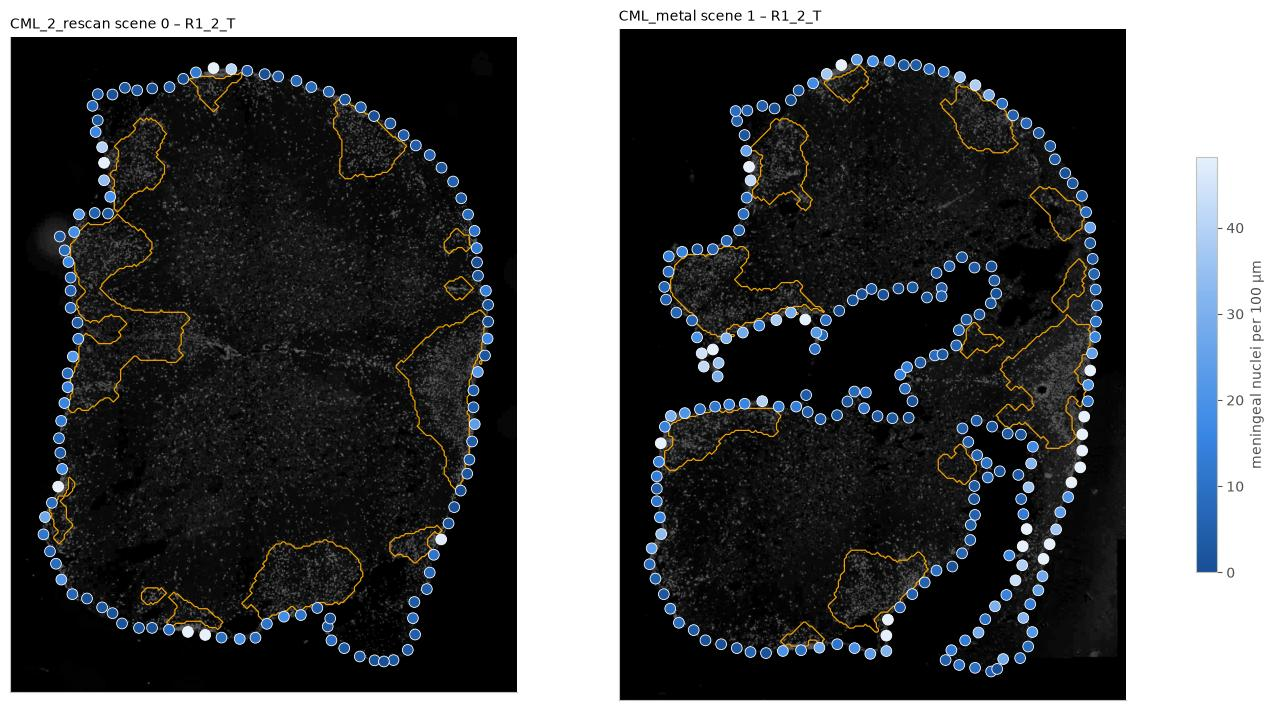

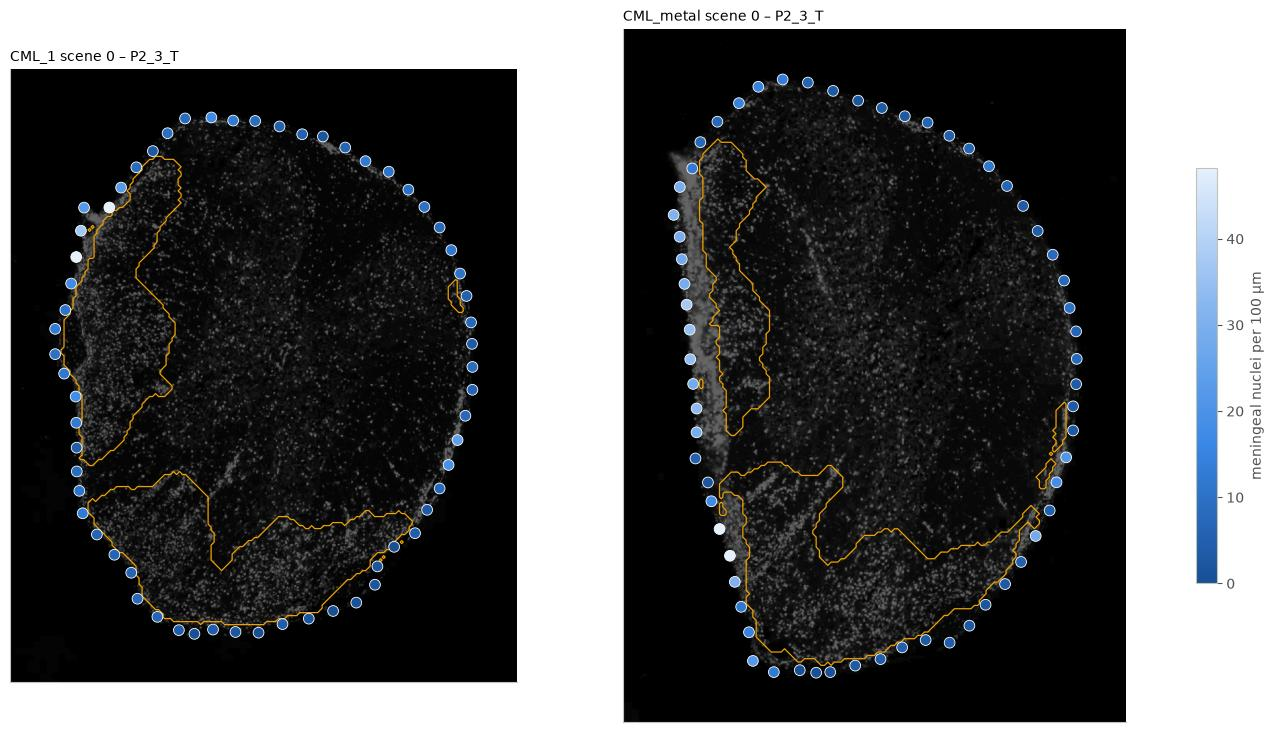

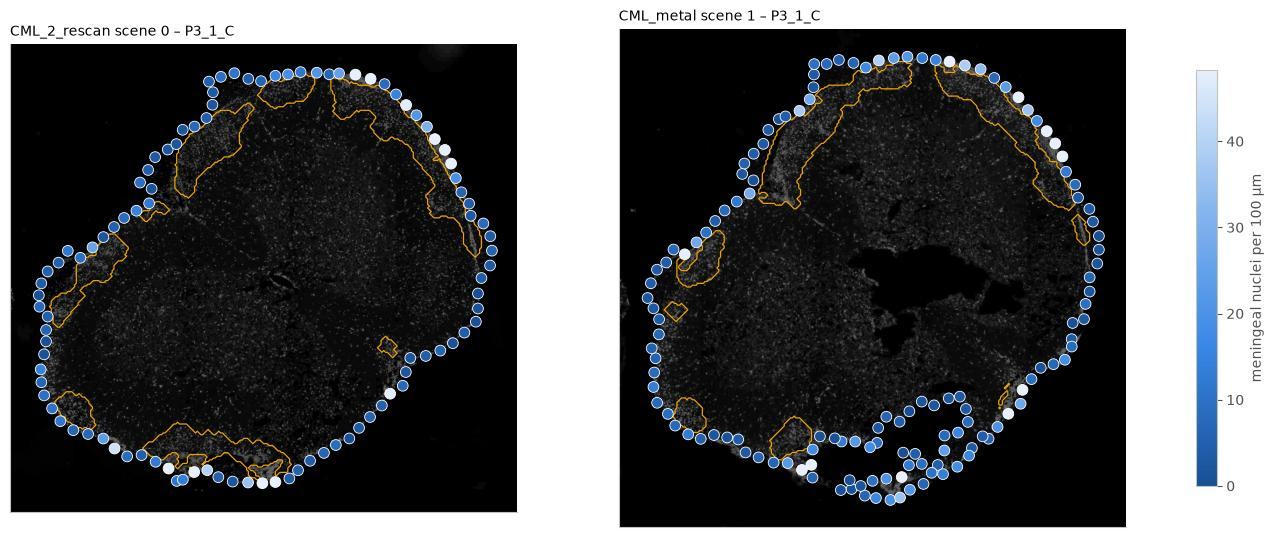

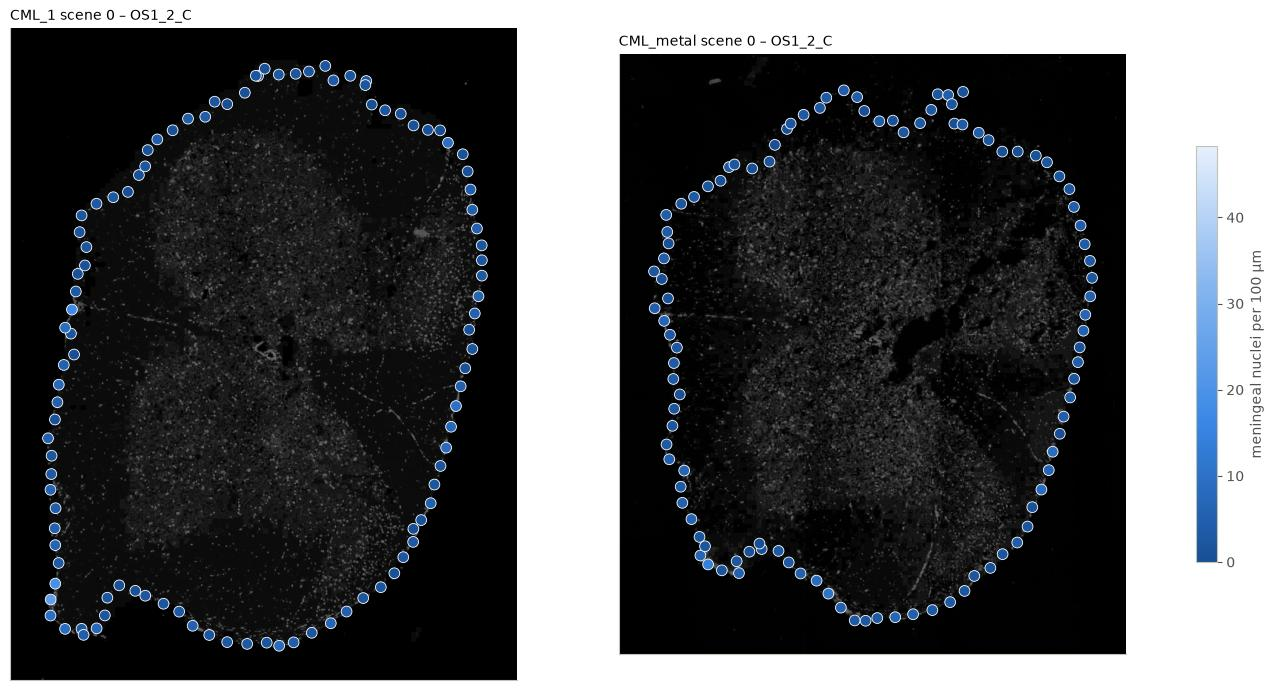

In [5]:
vmax = float(np.nanpercentile(seg.cells_per_100um, 98))
for sec in ["R1_2_T", "P2_3_T", "P3_1_C", "OS1_2_C"]:
    hits = [r for r in runs if sec in set(seg[seg.scene == r.name].section)]
    if not hits:
        continue
    fig, axes = plt.subplots(1, len(hits), figsize=(9 * len(hits), 9), squeeze=False)
    for ax, r in zip(axes.ravel(), hits):
        sc = S.plot_section_swelling(ax, r, seg, sec, "cells_per_100um", vmax=vmax)
    fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.6, label="meningeal nuclei per 100 µm")
    plt.show()

## The most swollen spots (150 µm zoom-ins)

The six segments with the highest cellularity, at most one per section and slide. Meningeal nuclei at full
strength (filled by elongation class as in notebook 09), everything else faded; meninges / buffer edges
drawn.

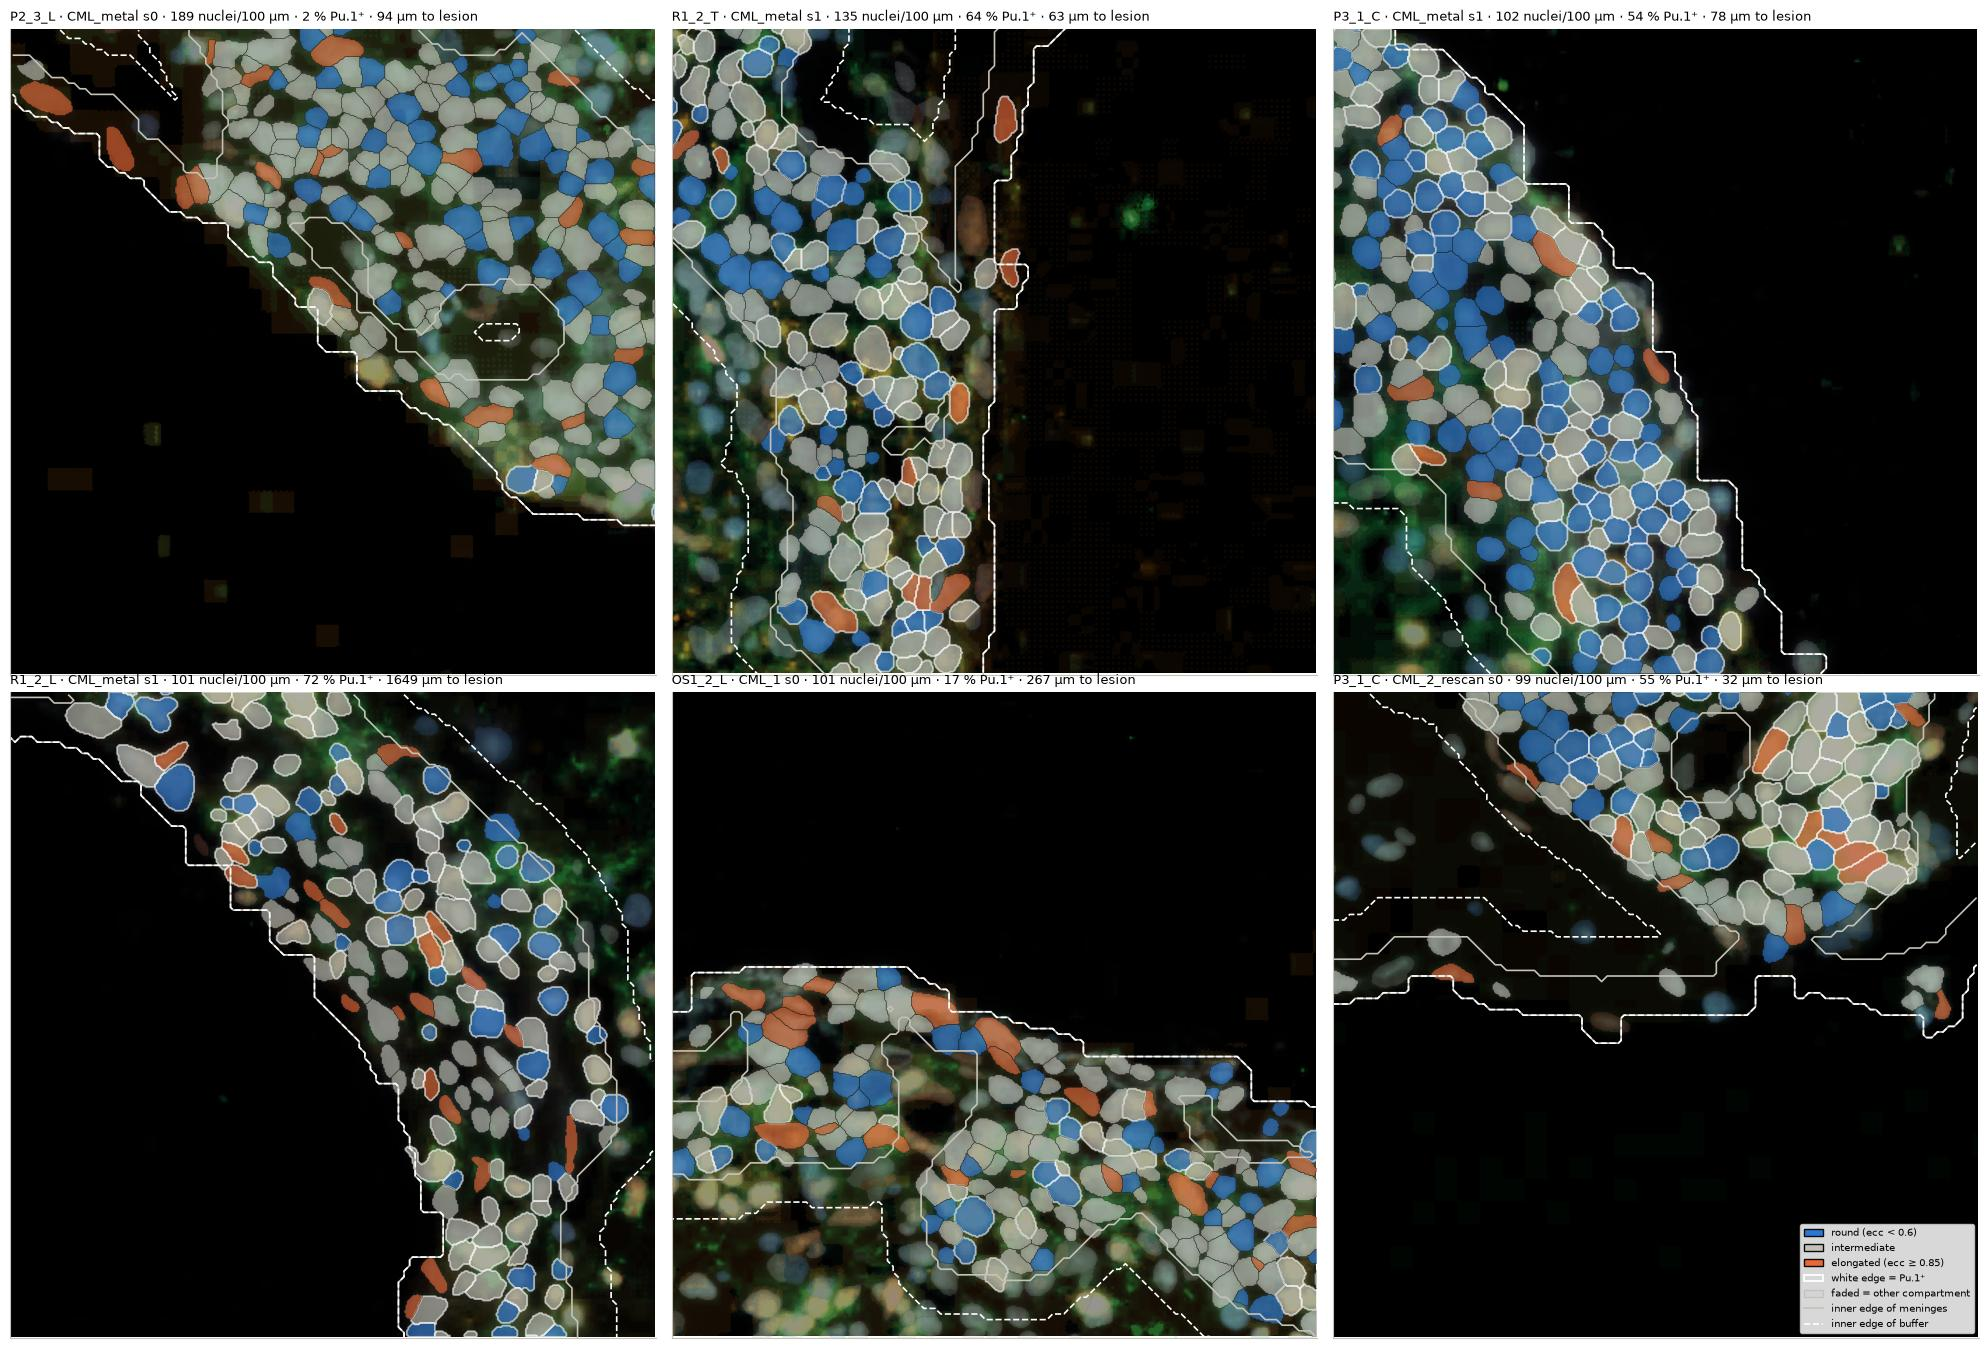

,scene,section,cells_per_100um,pu1_per_100um,thickness_um,dist_to_lesion_um
2226,CML_metal scene 0,P2_3_L,188.7,1.1,76.0,94.3
2580,CML_metal scene 1,R1_2_T,134.7,81.4,71.2,63.2
2699,CML_metal scene 1,P3_1_C,102.5,56.6,54.3,78.1
3260,CML_metal scene 1,R1_2_L,100.8,60.5,51.1,1649.1
287,CML_1 scene 0,OS1_2_L,100.7,15.7,49.3,266.8
965,CML_2_rescan scene 0,P3_1_C,98.6,63.6,75.5,31.6


In [6]:
top = seg.sort_values("cells_per_100um", ascending=False).drop_duplicates(["scene", "section"]).head(6)
byname = {r.name: r for r in runs}
fig, axes = plt.subplots(2, 3, figsize=(20, 13.5))
for ax, row in zip(axes.ravel(), top.itertuples()):
    r = byname[row.scene]
    comp = M.window_compartments(r.cells, E.compartment(r.cells))
    st_ = M.plot_nuclei(ax, r, r.cells, row.x_um, row.y_um, 150, comp=comp, focus="meninges")
    ax.set_title(f"{row.section} · {row.scene.replace(' scene ', ' s')} · {row.cells_per_100um:.0f} nuclei/100 µm · "
                 f"{100 * st_['pu1_focus']:.0f} % Pu.1⁺ · {row.dist_to_lesion_um:.0f} µm to lesion", loc="left", fontsize=9)
M.class_legend(axes.ravel()[-1])
plt.tight_layout(); plt.show()
display(top[["scene", "section", "cells_per_100um", "pu1_per_100um", "thickness_um", "dist_to_lesion_um"]].round(1))

## Reading

* Meningeal cellularity is a usable swelling measure: it rises toward lesions, is about twice as high in
  lesion sections as in control sections, and a much larger share of the near-lesion surface is swollen.
* With 8 lesion sections the paired near-vs-far test has little power; the consistency over sections and
  slides is the stronger evidence. Sections where a manual core reaches the surface (R1_3_L) show *less*
  meninges near the lesion – that is the protection rule, not biology.
* By animal, swelling separates disease from control: the adjuvant-only (CFA_L2) and OS1_2 animals have
  almost no swollen surface, the EAE animals 6–18 % – including EAE sections without lesions of their own
  (e.g. R1_2_L), so meningeal swelling is not confined to lesion sections.
* Thickness responds less because of how the boundary is built (10 µm floor, very strict growth); a
  dedicated meninges marker or annotation (option 1 earlier) would make thickness itself measurable.
* The traced surface follows tears in the section (e.g. CML_metal scene 1, R1_2_T); segments along a tear
  have little meninges and slightly dilute the far-from-lesion values.